# Adult Income 데이터 분석

**목표**: UCI Adult 데이터셋을 이용해 어떤 요인이 고소득(`income` > 50K) 여부에 영향을 미치는지 분석하고, 이를 예측하는 분류 모델을 만든다.

**진행 순서**
1. 데이터 로드 (pandas / polars)
2. 결측치 처리
3. EDA - 기술통계 및 상관계수
4. Seaborn 정적 차트
5. Plotly 인터랙티브 차트
6. t-test (age 기준, income 두 그룹 비교)
7. Pipeline 구성 (전처리 + 모델)
8. 모델 학습 및 평가 (accuracy, F1)

**데이터 출처**: https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data (헤더 없음, 결측치는 `" ?"` 로 표시됨)

In [1]:
import os

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import plotly.express as px
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

COLUMN_NAMES = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income",
]

NUMERIC_COLS = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CATEGORICAL_COLS = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
TARGET_COL = "income"

EDA_IMG_PATH = "eda_income_by_age.png"
CHART_HTML_PATH = "income_by_group.html"
MODEL_PATH = "income_pipeline.joblib"


def set_korean_font() -> str:
    installed = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
    font_name = next((f for f in candidates if f in installed), "DejaVu Sans")
    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False
    if font_name == "DejaVu Sans":
        print("한글 폰트를 찾지 못해 그래프 제목이 깨질 수 있습니다.")
    return font_name

## 1. 데이터 로드

- `DATA_URL`에서 헤더 없이 CSV를 읽고 `COLUMN_NAMES`를 지정한다.
- 공백이 섞여 있으므로(`" <=50K"`, `" Private"` 등) 문자열 컬럼은 strip 처리한다.
- 결측치가 `"?"` 문자열로 표시되어 있으므로 이를 NaN(pandas) / null(polars)로 변환한다.
- pandas 버전과 polars 버전을 각각 만들어 이후 단계에서 비교한다.

In [2]:
def load_data_pandas(url: str = DATA_URL) -> pd.DataFrame:
    """pandas로 Adult 데이터를 로드하고 문자열 정리 + 결측치(NaN) 변환까지 수행한다."""
    df = pd.read_csv(url, header=None, names=COLUMN_NAMES, na_values="?", skipinitialspace=True)
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())
    return df


def load_data_polars(url: str = DATA_URL) -> pl.DataFrame:
    """polars로 Adult 데이터를 로드하고 문자열 정리 + 결측치(null) 변환까지 수행한다."""
    df = pl.read_csv(url, has_header=False, new_columns=COLUMN_NAMES)
    str_cols = [c for c, dt in zip(df.columns, df.dtypes) if dt == pl.Utf8]
    df = df.with_columns([pl.col(c).str.strip_chars() for c in str_cols])
    df = df.with_columns(
        [pl.when(pl.col(c) == "?").then(None).otherwise(pl.col(c)).alias(c) for c in str_cols]
    )
    return df


df_pd = load_data_pandas()
df_pl = load_data_polars()

print("pandas shape:", df_pd.shape)
print("polars shape:", df_pl.shape)
df_pd.head()

/var/folders/ct/3lql59js5796vxlv796q619m0000gn/T/ipykernel_17892/2189158117.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


pandas shape: (32561, 15)
polars shape: (32562, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. 결측치 처리

- 컬럼별 결측 개수/비율을 pandas, polars 각각 출력한다.
- 결측이 있는 컬럼(workclass, occupation, native-country 등)에 대해 제거할지 최빈값으로 대체할지 결정하고 이유를 적는다.
- 처리 후 shape 변화를 pandas/polars 각각 출력해 비교한다.

In [3]:
def report_missing_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """컬럼별 결측 개수/비율을 정리한 DataFrame을 반환한다."""
    counts = df.isna().sum()
    ratio = (counts / len(df) * 100).round(2)
    return pd.DataFrame({"missing_count": counts, "missing_pct": ratio})


def report_missing_polars(df: pl.DataFrame) -> pl.DataFrame:
    """컬럼별 결측 개수/비율을 정리한 DataFrame을 반환한다."""
    counts = df.null_count()
    n = df.height
    report = counts.transpose(include_header=True, header_name="column", column_names=["missing_count"])
    report = report.with_columns((pl.col("missing_count") / n * 100).round(2).alias("missing_pct"))
    return report


def handle_missing_pandas(df: pd.DataFrame) -> pd.DataFrame:
    """결측치를 처리한 pandas DataFrame을 반환한다.

    결측 비율이 가장 높은 컬럼(occupation)도 6% 미만이라 최빈값 대체보다는
    행 제거가 데이터 왜곡을 줄이면서도 손실을 최소화하는 방법이라 판단해 dropna를 사용한다.
    """
    return df.dropna().reset_index(drop=True)


def handle_missing_polars(df: pl.DataFrame) -> pl.DataFrame:
    """결측치를 처리한 polars DataFrame을 반환한다 (pandas와 동일한 전략: 행 제거)."""
    return df.drop_nulls()


print(report_missing_pandas(df_pd))
print(report_missing_polars(df_pl))

df_pd_clean = handle_missing_pandas(df_pd)
df_pl_clean = handle_missing_polars(df_pl)

print("pandas shape (처리 전/후):", df_pd.shape, "->", df_pd_clean.shape)
print("polars shape (처리 전/후):", df_pl.shape, "->", df_pl_clean.shape)

                missing_count  missing_pct
age                         0         0.00
workclass                1836         5.64
fnlwgt                      0         0.00
education                   0         0.00
education-num               0         0.00
marital-status              0         0.00
occupation               1843         5.66
relationship                0         0.00
race                        0         0.00
sex                         0         0.00
capital-gain                0         0.00
capital-loss                0         0.00
hours-per-week              0         0.00
native-country            583         1.79
income                      0         0.00
shape: (15, 3)
┌────────────────┬───────────────┬─────────────┐
│ column         ┆ missing_count ┆ missing_pct │
│ ---            ┆ ---           ┆ ---         │
│ str            ┆ u32           ┆ f64         │
╞════════════════╪═══════════════╪═════════════╡
│ age            ┆ 1             ┆ 0.0         │
│ w

## 2-1. 이상치 확인 (Outlier Check)

결측치 처리로 만든 `df_pd_clean`을 대상으로 IQR(사분위수 범위) 기준 이상치를 확인한다.
박스플롯으로 시각화하고, 컬럼별 이상치 개수/비율을 표로 정리한다.

In [4]:
def summarize_iqr_outliers(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    """IQR(Q1-1.5*IQR ~ Q3+1.5*IQR) 기준으로 컬럼별 이상치 개수/비율을 정리한 표를 반환한다."""
    rows = []
    for col in numeric_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = int(((df[col] < lower) | (df[col] > upper)).sum())
        rows.append({
            "column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
            "lower_bound": lower, "upper_bound": upper,
            "outlier_count": n_outliers,
            "outlier_pct": round(n_outliers / len(df) * 100, 2),
        })
    return pd.DataFrame(rows)


iqr_summary = summarize_iqr_outliers(df_pd_clean, NUMERIC_COLS)
iqr_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,age,28.00,47.0,19.00,-0.500,75.500,169,0.56
1,fnlwgt,117627.25,237628.5,120001.25,-62374.625,417630.375,903,2.99
2,education-num,9.00,13.0,4.00,3.000,19.000,196,0.65
3,capital-gain,0.00,0.0,0.00,0.000,0.000,2538,8.41
4,capital-loss,0.00,0.0,0.00,0.000,0.000,1427,4.73
5,hours-per-week,40.00,45.0,5.00,32.500,52.500,7953,26.37


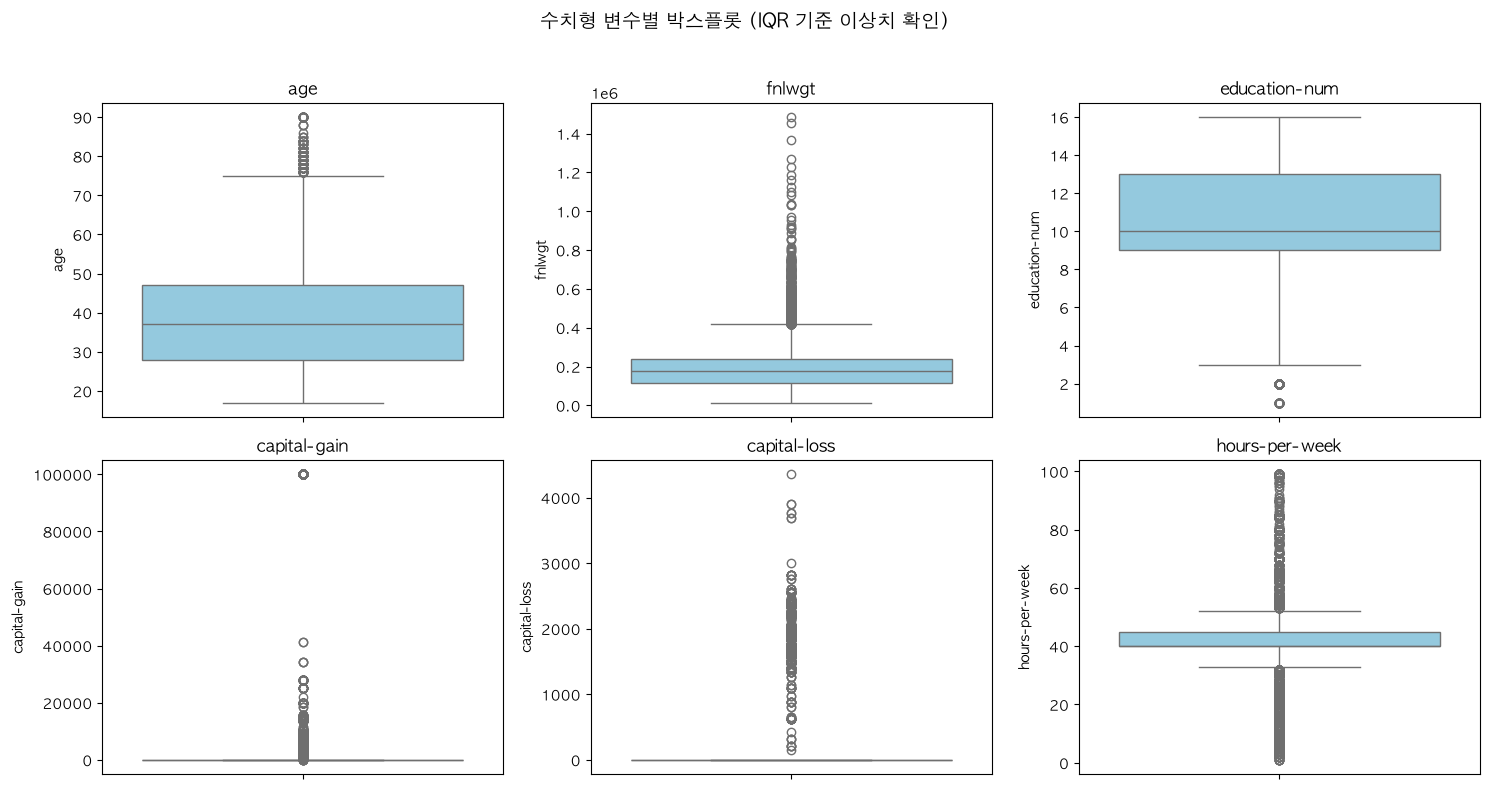

In [5]:
OUTLIER_BOXPLOT_PATH = "outlier_boxplots.png"


def plot_outlier_boxplots(df: pd.DataFrame, numeric_cols: list[str], save_path: str = OUTLIER_BOXPLOT_PATH) -> None:
    """수치형 변수별 박스플롯을 2x3 그리드로 그려 IQR 기준 이상치(점)를 시각적으로 보여준다."""
    set_korean_font()
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, col in zip(axes.flat, numeric_cols):
        sns.boxplot(y=df[col], ax=ax, color="skyblue")
        ax.set_title(col)
        ax.set_ylabel(col)
    fig.suptitle("수치형 변수별 박스플롯 (IQR 기준 이상치 확인)", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, dpi=120)
    plt.show()


plot_outlier_boxplots(df_pd_clean, NUMERIC_COLS)

박스플롯에서 `capital-gain`/`capital-loss`는 상자(box)가 거의 안 보이고 점(이상치)만 잔뜩 찍혀 있다.
`hours-per-week`도 이상치 비율이 26%대로 비정상적으로 높다. IQR 계산 결과(Q1=Q3=0인 경우가 있는지 등)를
실제 분포와 같이 확인해본다.

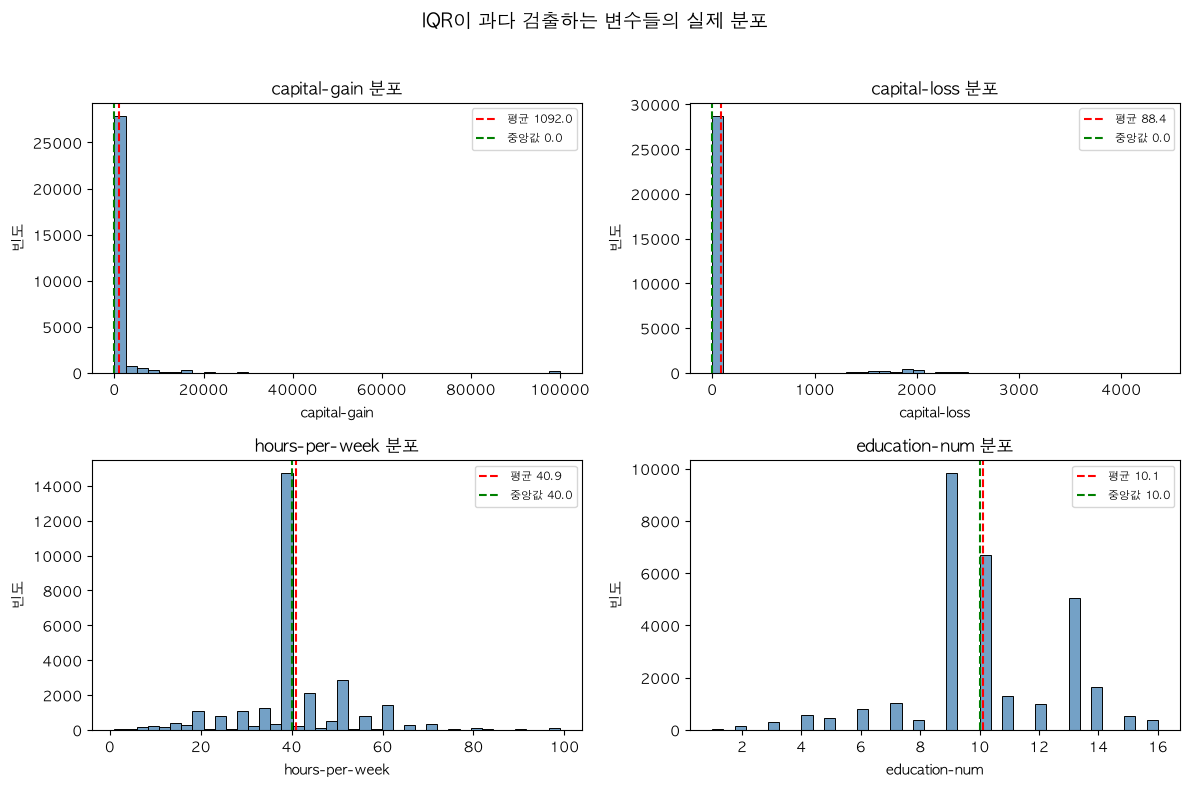

In [6]:
OUTLIER_HIST_PATH = "outlier_distributions.png"
PROBLEM_COLS = ["capital-gain", "capital-loss", "hours-per-week", "education-num"]


def plot_zero_inflation_hist(df: pd.DataFrame, cols: list[str], save_path: str = OUTLIER_HIST_PATH) -> None:
    """IQR이 과다 검출하는 변수들의 실제 분포(0 쏠림 / 특정값 스파이크)를 히스토그램으로 보여준다."""
    set_korean_font()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col in zip(axes.flat, cols):
        sns.histplot(df[col], bins=40, ax=ax, color="steelblue")
        ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"평균 {df[col].mean():.1f}")
        ax.axvline(df[col].median(), color="green", linestyle="--", label=f"중앙값 {df[col].median():.1f}")
        ax.set_title(f"{col} 분포")
        ax.set_xlabel(col)
        ax.set_ylabel("빈도")
        ax.legend(fontsize=8)
    fig.suptitle("IQR이 과다 검출하는 변수들의 실제 분포", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, dpi=120)
    plt.show()


plot_zero_inflation_hist(df_pd_clean, PROBLEM_COLS)

### IQR 외에 고려해야 할 것

- **분포 모양을 먼저 본다.** `capital-gain`/`capital-loss`는 대부분 0에 몰려 있어 Q1=Q3=0이 되고,
  IQR도 0이 되어버린다. 그 결과 0이 아닌 모든 값이 기계적으로 "이상치"로 잡힌다 — 통계량이 아니라
  분포 자체가 이 방법과 안 맞는 경우다. `hours-per-week`도 40시간에 표본이 몰려있어 비슷한 문제가 생긴다.
- **Z-score도 근본적으로 같은 한계가 있다.** 정규분포를 가정하는 방법이라, 위처럼 한쪽으로 쏠리거나
  특정 값에 표본이 몰린 분포에는 IQR과 마찬가지로 잘 맞지 않는다.
- **타겟 변수와의 관계를 확인한다.** `hours-per-week`가 높은 사람일수록 `income`이 `>50K`인 경향이 있다
  (6절 t-test 참고). 즉 IQR이 잡아낸 "이상치"가 실제로는 우리가 예측하려는 신호일 수 있다 — 통계적으로
  드문 값(rare value)과 데이터 오류(error)는 다르다.
- **측정/수집 방식에서 생기는 인위적 상한(top-coding)인지 확인한다.** `capital-gain`의 최댓값이
  99999로 고정돼 있는데, 이는 원 센서스 조사에서 상한을 씌운 값으로 알려져 있다 — 제거 대상이 아니라
  "데이터 수집 한계"로 보고서에 별도로 언급해야 하는 항목이다.
- **다변량 관점도 있다는 것만 인지해둔다.** 지금 본 건 컬럼 하나씩 보는 단변량 방법(IQR, Z-score)이다.
  값 하나하나는 정상 범위여도 조합이 이상한 경우(예: 나이 17세에 근속연수가 매우 긴 경우)는
  Isolation Forest, LOF(Local Outlier Factor) 같은 다변량 방법이 필요하며, 이번 분석 범위에서는 다루지 않는다.

**결론**: 이 데이터셋은 이미 정제되어 배포된 벤치마크 데이터이고, IQR이 과다 검출하는 변수들은
실제로는 정상적인 값(파트타임/초과근무, 자본소득 있음/없음)이거나 예측 신호 그 자체다. 따라서
**IQR 기반 행 제거는 적용하지 않는다.** 대신 `capital-gain`의 상한 캡(99999)만 보고서에 한계점으로 명시한다.

## 3. EDA - 기술통계 및 상관계수

- `describe()`로 수치형 변수 기술통계를 pandas/polars 각각 출력한다.
- 수치형 변수 간 상관계수 행렬을 출력한다.
- `income` 그룹별 groupby 요약(평균 age, hours-per-week 등)을 출력한다.

In [7]:
# 기술통계 (pandas)
print("=== pandas describe ===")
print(df_pd_clean[NUMERIC_COLS].describe())

# 기술통계 (polars)
print("\n=== polars describe ===")
print(df_pl_clean.select(NUMERIC_COLS).describe())

# 상관계수 행렬
print("\n=== 상관계수 행렬 ===")
print(df_pd_clean[NUMERIC_COLS].corr())

# income 그룹별 요약
print("\n=== income 그룹별 요약 (평균) ===")
print(df_pd_clean.groupby(TARGET_COL)[NUMERIC_COLS].mean())

=== pandas describe ===
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  30162.000000  3.016200e+04   30162.000000  30162.000000  30162.000000   
mean      38.437902  1.897938e+05      10.121312   1092.007858     88.372489   
std       13.134665  1.056530e+05       2.549995   7406.346497    404.298370   
min       17.000000  1.376900e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.176272e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.784250e+05      10.000000      0.000000      0.000000   
75%       47.000000  2.376285e+05      13.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    30162.000000  
mean        40.931238  
std         11.979984  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

=== polars describe ===
shape: (9, 7)


## 4. Seaborn 정적 차트

- income 그룹(`<=50K` / `>50K`)별 age 분포를 비교하는 정적 차트를 그린다 (예: boxplot 또는 histplot+kde).
- 제목, x축/y축 레이블을 반드시 포함한다.
- 결과를 `EDA_IMG_PATH`에 저장한다.

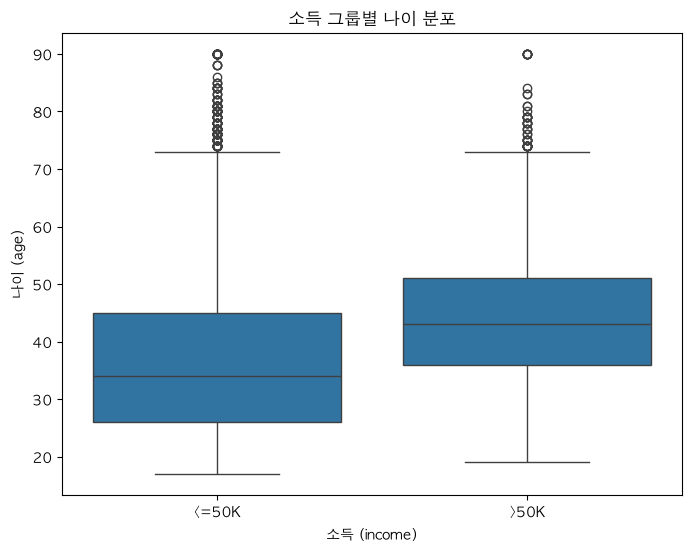

In [8]:
def plot_age_by_income(df: pd.DataFrame, save_path: str = EDA_IMG_PATH) -> None:
    """income 그룹별 age 분포를 비교하는 seaborn 정적 차트를 그리고 저장한다."""
    set_korean_font()
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=TARGET_COL, y="age")
    plt.title("소득 그룹별 나이 분포")
    plt.xlabel("소득 (income)")
    plt.ylabel("나이 (age)")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_age_by_income(df_pd_clean)

## 5. Plotly 인터랙티브 차트

- education 또는 occupation 등 범주형 변수별 고소득(`>50K`) 비율을 비교하는 인터랙티브 막대차트를 그린다.
- 제목, x축/y축 레이블을 반드시 포함한다.
- 결과를 `CHART_HTML_PATH`에 HTML로 저장한다.

In [9]:
def plot_income_rate_by_group(df: pd.DataFrame, group_col: str = "education", save_path: str = CHART_HTML_PATH):
    """group_col별 고소득 비율을 계산해 plotly 막대차트로 그리고 html로 저장한다."""
    rate = (
        df.assign(is_high_income=(df[TARGET_COL] == ">50K").astype(int))
        .groupby(group_col)["is_high_income"]
        .mean()
        .mul(100)
        .reset_index(name="income_rate_pct")
        .sort_values("income_rate_pct", ascending=False)
    )

    fig = px.bar(
        rate,
        x=group_col,
        y="income_rate_pct",
        title=f"{group_col}별 고소득(>50K) 비율",
        labels={group_col: group_col, "income_rate_pct": "고소득 비율 (%)"},
    )
    fig.write_html(save_path)
    return fig


fig = plot_income_rate_by_group(df_pd_clean)
fig.show()

## 6. t-test (age 기준)

- income `<=50K` 그룹과 `>50K` 그룹의 평균 age를 비교한다.
- 귀무가설(H0): 두 그룹의 평균 age는 같다.
- 대립가설(H1): 두 그룹의 평균 age는 다르다.
- `scipy.stats.ttest_ind` 결과(t-statistic, p-value)를 출력하고, 유의수준(0.05) 기준으로 해석 문장을 출력한다.

In [10]:
def run_ttest_age_by_income(df: pd.DataFrame, alpha: float = 0.05) -> None:
    """income 두 그룹 간 age 평균 차이를 t-test로 검정하고 결과를 해석해 출력한다."""
    group_low = df.loc[df[TARGET_COL] == "<=50K", "age"]
    group_high = df.loc[df[TARGET_COL] == ">50K", "age"]

    t_stat, p_value = stats.ttest_ind(group_low, group_high, equal_var=False)

    print(f"<=50K 그룹 평균 age: {group_low.mean():.2f} (n={len(group_low)})")
    print(f">50K  그룹 평균 age: {group_high.mean():.2f} (n={len(group_high)})")
    print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4e}")

    if p_value < alpha:
        print(f"p-value({p_value:.4e}) < alpha({alpha}) → 귀무가설(H0) 기각: 두 그룹의 평균 age는 유의하게 다르다.")
    else:
        print(f"p-value({p_value:.4e}) >= alpha({alpha}) → 귀무가설(H0) 채택: 두 그룹의 평균 age가 다르다고 볼 근거가 부족하다.")


run_ttest_age_by_income(df_pd_clean)

<=50K 그룹 평균 age: 36.61 (n=22654)
>50K  그룹 평균 age: 43.96 (n=7508)
t-statistic: -49.5047, p-value: 0.0000e+00
p-value(0.0000e+00) < alpha(0.05) → 귀무가설(H0) 기각: 두 그룹의 평균 age는 유의하게 다르다.


## 7. Pipeline 구성

- `ColumnTransformer`로 수치형(`NUMERIC_COLS`)은 `StandardScaler`, 범주형(`CATEGORICAL_COLS`)은 `OneHotEncoder`로 전처리한다.
- 전처리 + 분류 모델(`LogisticRegression` 등)을 하나의 `Pipeline`으로 묶는다.

In [11]:
def build_pipeline() -> Pipeline:
    """전처리(ColumnTransformer) + 분류 모델을 하나로 묶은 Pipeline을 반환한다."""
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ]
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=1000)),
        ]
    )


pipeline = build_pipeline()
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## 8. 모델 학습 및 평가

- `train_test_split`으로 학습/평가 데이터를 분리한다.
- Pipeline을 학습시키고 평가 데이터에 대해 예측한다.
- accuracy, F1-score, classification_report를 출력한다.
- 학습된 Pipeline을 `MODEL_PATH`에 저장한다.

In [12]:
X = df_pd_clean[NUMERIC_COLS + CATEGORICAL_COLS]
y = df_pd_clean[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=">50K")

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score (>50K): {f1:.4f}")
print(classification_report(y_test, y_pred))

joblib.dump(pipeline, MODEL_PATH)
print(f"모델 저장 완료: {MODEL_PATH}")

Accuracy: 0.8475
F1-score (>50K): 0.6640
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4531
        >50K       0.74      0.61      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.77      0.78      6033
weighted avg       0.84      0.85      0.84      6033

모델 저장 완료: income_pipeline.joblib
